### Dataset preparation
Here in this project, MovieLens dataset is used to build this netflix-style recommendation system. Three important csv files are used to build this system such as "rating.csv", "movie.csv", and "tag.csv". The csv files are loaded and merged using the common column into a single dataset for exploratory data analysis and preprocessing.

In [2]:
#importing libraries
import pandas as pd
import numpy as np

In [3]:
ls

 Volume in drive C is Windows-SSD
 Volume Serial Number is 1283-82A2

 Directory of C:\Users\Pradheesha\Downloads\Netflix recommendation system

04-04-2026  22:13    <DIR>          .
04-04-2026  11:59    <DIR>          ..
04-04-2026  16:07    <DIR>          .ipynb_checkpoints
04-04-2026  22:13            84,426 EDA and Preprocessing.ipynb
04-04-2026  11:58         1,493,648 movie.csv
04-04-2026  11:59       690,353,377 rating.csv
04-04-2026  11:58        21,725,514 tag.csv
               4 File(s)    713,656,965 bytes
               3 Dir(s)  360,340,516,864 bytes free


In [4]:
#dataset loading for performing preprocessing
ratings = pd.read_csv("C:\\Users\\Pradheesha\\Downloads\\Netflix recommendation system\\rating.csv")
movies = pd.read_csv("C:\\Users\\Pradheesha\\Downloads\\Netflix recommendation system\\movie.csv")
tags = pd.read_csv("C:\\Users\\Pradheesha\\Downloads\\Netflix recommendation system\\tag.csv")

In [5]:
#merging the separate csv files into a single dataset
df = ratings.merge(movies, on='movieId')
df = df.merge(tags, on=['userId','movieId'], how='left')

### Performing the EDA
Exploratory data analysis is performed to understand the shape of the dataset. Then, the null values are determined in the dataset and imputed.

In [6]:
df.shape

(20265625, 8)

In [7]:
#statement to display the first few rows of the merged dataset
df.head()

,userId,movieId,rating,timestamp_x,title,genres,tag,timestamp_y
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy,NaN,NaN
1,1,29,3.5,2005-04-02 23:31:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,NaN,NaN
2,1,32,3.5,2005-04-02 23:33:39,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,NaN,NaN
3,1,47,3.5,2005-04-02 23:32:07,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,NaN,NaN
4,1,50,3.5,2005-04-02 23:29:40,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,NaN,NaN


In [8]:
#The data types of each column and memory usage are determined using this info() method
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20265625 entries, 0 to 20265624
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   userId       int64  
 1   movieId      int64  
 2   rating       float64
 3   timestamp_x  object 
 4   title        object 
 5   genres       object 
 6   tag          object 
 7   timestamp_y  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.2+ GB


In [9]:
#various statistical measures of the dataset are determined using describe()
df.describe()

,userId,movieId,rating
count,2.026562e+07,2.026562e+07,2.026562e+07
mean,6.901928e+04,9.376877e+03,3.529365e+00
std,4.007377e+04,2.030789e+04,1.052108e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.429500e+04,9.080000e+02,3.000000e+00
50%,6.907200e+04,2.203000e+03,4.000000e+00
75%,1.036540e+05,4.878000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [10]:
#removing the column "timestamp_y" becasue the tag time is not important for recommendation logic
df.drop(columns=['timestamp_y'], inplace=True)

In [11]:
#renaming the column "timestamp_x" to "timestamp" in order to have clear understanding
df.rename(columns={'timestamp_x': 'timestamp'}, inplace=True)

In [12]:
#determing the count of missing values in the dataset
df.isnull().sum()

userId              0
movieId             0
rating              0
timestamp           0
title               0
genres              0
tag          19874181
dtype: int64

In [13]:
#statement to determine the percentage of missing values in the dataset
(df.isnull().sum() / len(df)) * 100

userId        0.000000
movieId       0.000000
rating        0.000000
timestamp     0.000000
title         0.000000
genres        0.000000
tag          98.068434
dtype: float64

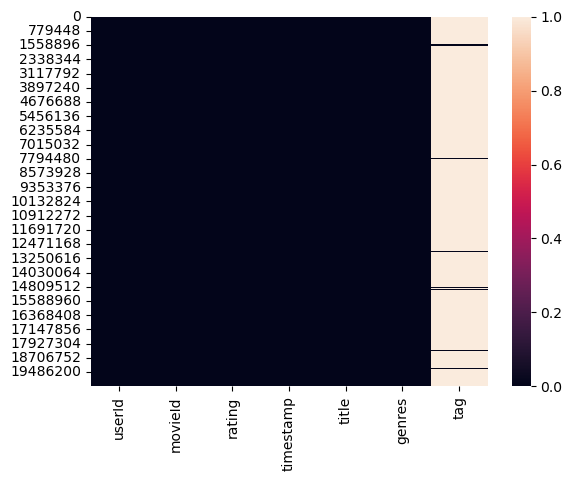

In [15]:
#code to visualise the null value using matplotlib and seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=True)
plt.show()

In [14]:
#handling the missing values. The values are Missing At Random since the tagging value miss is based on user behaviour
df['tag_missing'] = df['tag'].isnull().astype(int)
df['tag'] = df['tag'].fillna('')
df.head()

,userId,movieId,rating,timestamp,title,genres,tag,tag_missing
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy,,1
1,1,29,3.5,2005-04-02 23:31:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,,1
2,1,32,3.5,2005-04-02 23:33:39,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,,1
3,1,47,3.5,2005-04-02 23:32:07,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,,1
4,1,50,3.5,2005-04-02 23:29:40,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,,1


In [15]:
#statement to check for duplicate values
df.duplicated().sum()

np.int64(0)

### Feature engineering

In [16]:
#creating a new feature "user_avg_rating"
df['user_avg_rating'] = df.groupby('userId')['rating'].transform('mean')

#creating a new feature "movie_avg_rating"
df['movie_avg_rating'] = df.groupby('movieId')['rating'].transform('mean')

In [17]:
#performing one-hot encoding on the "genre" categorical feature to convert it into numerical feature
genre_dummies = df['genres'].str.get_dummies(sep='|')
df = pd.concat([df, genre_dummies], axis=1)

In [18]:
df.head()

,userId,movieId,rating,timestamp,title,genres,tag,tag_missing,user_avg_rating,movie_avg_rating,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy,,1,3.742857,3.213844,...,0,0,0,0,0,0,0,0,0,0
1,1,29,3.5,2005-04-02 23:31:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,,1,3.742857,3.955775,...,0,0,0,0,1,0,1,0,0,0
2,1,32,3.5,2005-04-02 23:33:39,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,,1,3.742857,3.902560,...,0,0,0,0,1,0,1,1,0,0
3,1,47,3.5,2005-04-02 23:32:07,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,,1,3.742857,4.056273,...,0,0,0,0,1,0,0,1,0,0
4,1,50,3.5,2005-04-02 23:29:40,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,,1,3.742857,4.334675,...,0,0,0,0,1,0,0,1,0,0


In [20]:
#save the preprocessed data
df.to_csv("C:\\Users\\Pradheesha\\Downloads\\Netflix recommendation system\\processed_df.csv", index=False)

In [21]:
df.tail()

,userId,movieId,rating,timestamp,title,genres,tag,tag_missing,user_avg_rating,movie_avg_rating,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
20265620,138493,68954,4.5,2009-11-13 15:42:00,Up (2009),Adventure|Animation|Children|Drama,,1,4.172922,4.042431,...,0,0,0,0,0,0,0,0,0,0
20265621,138493,69526,4.5,2009-12-03 18:31:48,Transformers: Revenge of the Fallen (2009),Action|Adventure|Sci-Fi|IMAX,,1,4.172922,2.928438,...,0,0,1,0,0,0,1,0,0,0
20265622,138493,69644,3.0,2009-12-07 18:10:57,Ice Age: Dawn of the Dinosaurs (2009),Action|Adventure|Animation|Children|Comedy|Rom...,,1,4.172922,3.386051,...,0,0,0,0,0,1,0,0,0,0
20265623,138493,70286,5.0,2009-11-13 15:42:24,District 9 (2009),Mystery|Sci-Fi|Thriller,,1,4.172922,3.893906,...,0,0,0,0,1,0,1,1,0,0
20265624,138493,71619,2.5,2009-10-17 20:25:36,Coco Before Chanel (Coco avant Chanel) (2009),Drama,,1,4.172922,3.432203,...,0,0,0,0,0,0,0,0,0,0


### final features after preprocessing to train the model for colloborative filtering
* userId
* movieId
* rating
* timestamp
* title
* genre_dummies
* tag_missing
* user_avg_rating
* movie_avg_rating